In [1]:
import shutil

src = "/kaggle/input/datasets/bhuvanwarrior"
dst = "/kaggle/working/weapon_dataset"

shutil.copytree(src, dst)

print("Dataset copied!")

Dataset copied!


In [2]:
import os

print(os.listdir("/kaggle/working/weapon_dataset"))

['weapon-detection-yolov12']


In [3]:
import os

base = "/kaggle/working/weapon_dataset/weapon-detection-yolov12"

for split in ["train", "valid", "test"]:
    label_path = os.path.join(base, split, "labels")
    
    for file in os.listdir(label_path):
        file_path = os.path.join(label_path, file)
        
        new_lines = []
        
        with open(file_path, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            
            if len(parts) == 0:
                continue
            
            cls = int(parts[0])
            
            # ❌ remove undefined
            if cls == 1:
                continue
            
            # ✅ convert to weapon
            parts[0] = "0"
            new_lines.append(" ".join(parts))
        
        with open(file_path, "w") as f:
            f.write("\n".join(new_lines))

print("Labels cleaned!")

Labels cleaned!


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00a 0:00:01


In [5]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")

results = model.train(
    data="/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, 

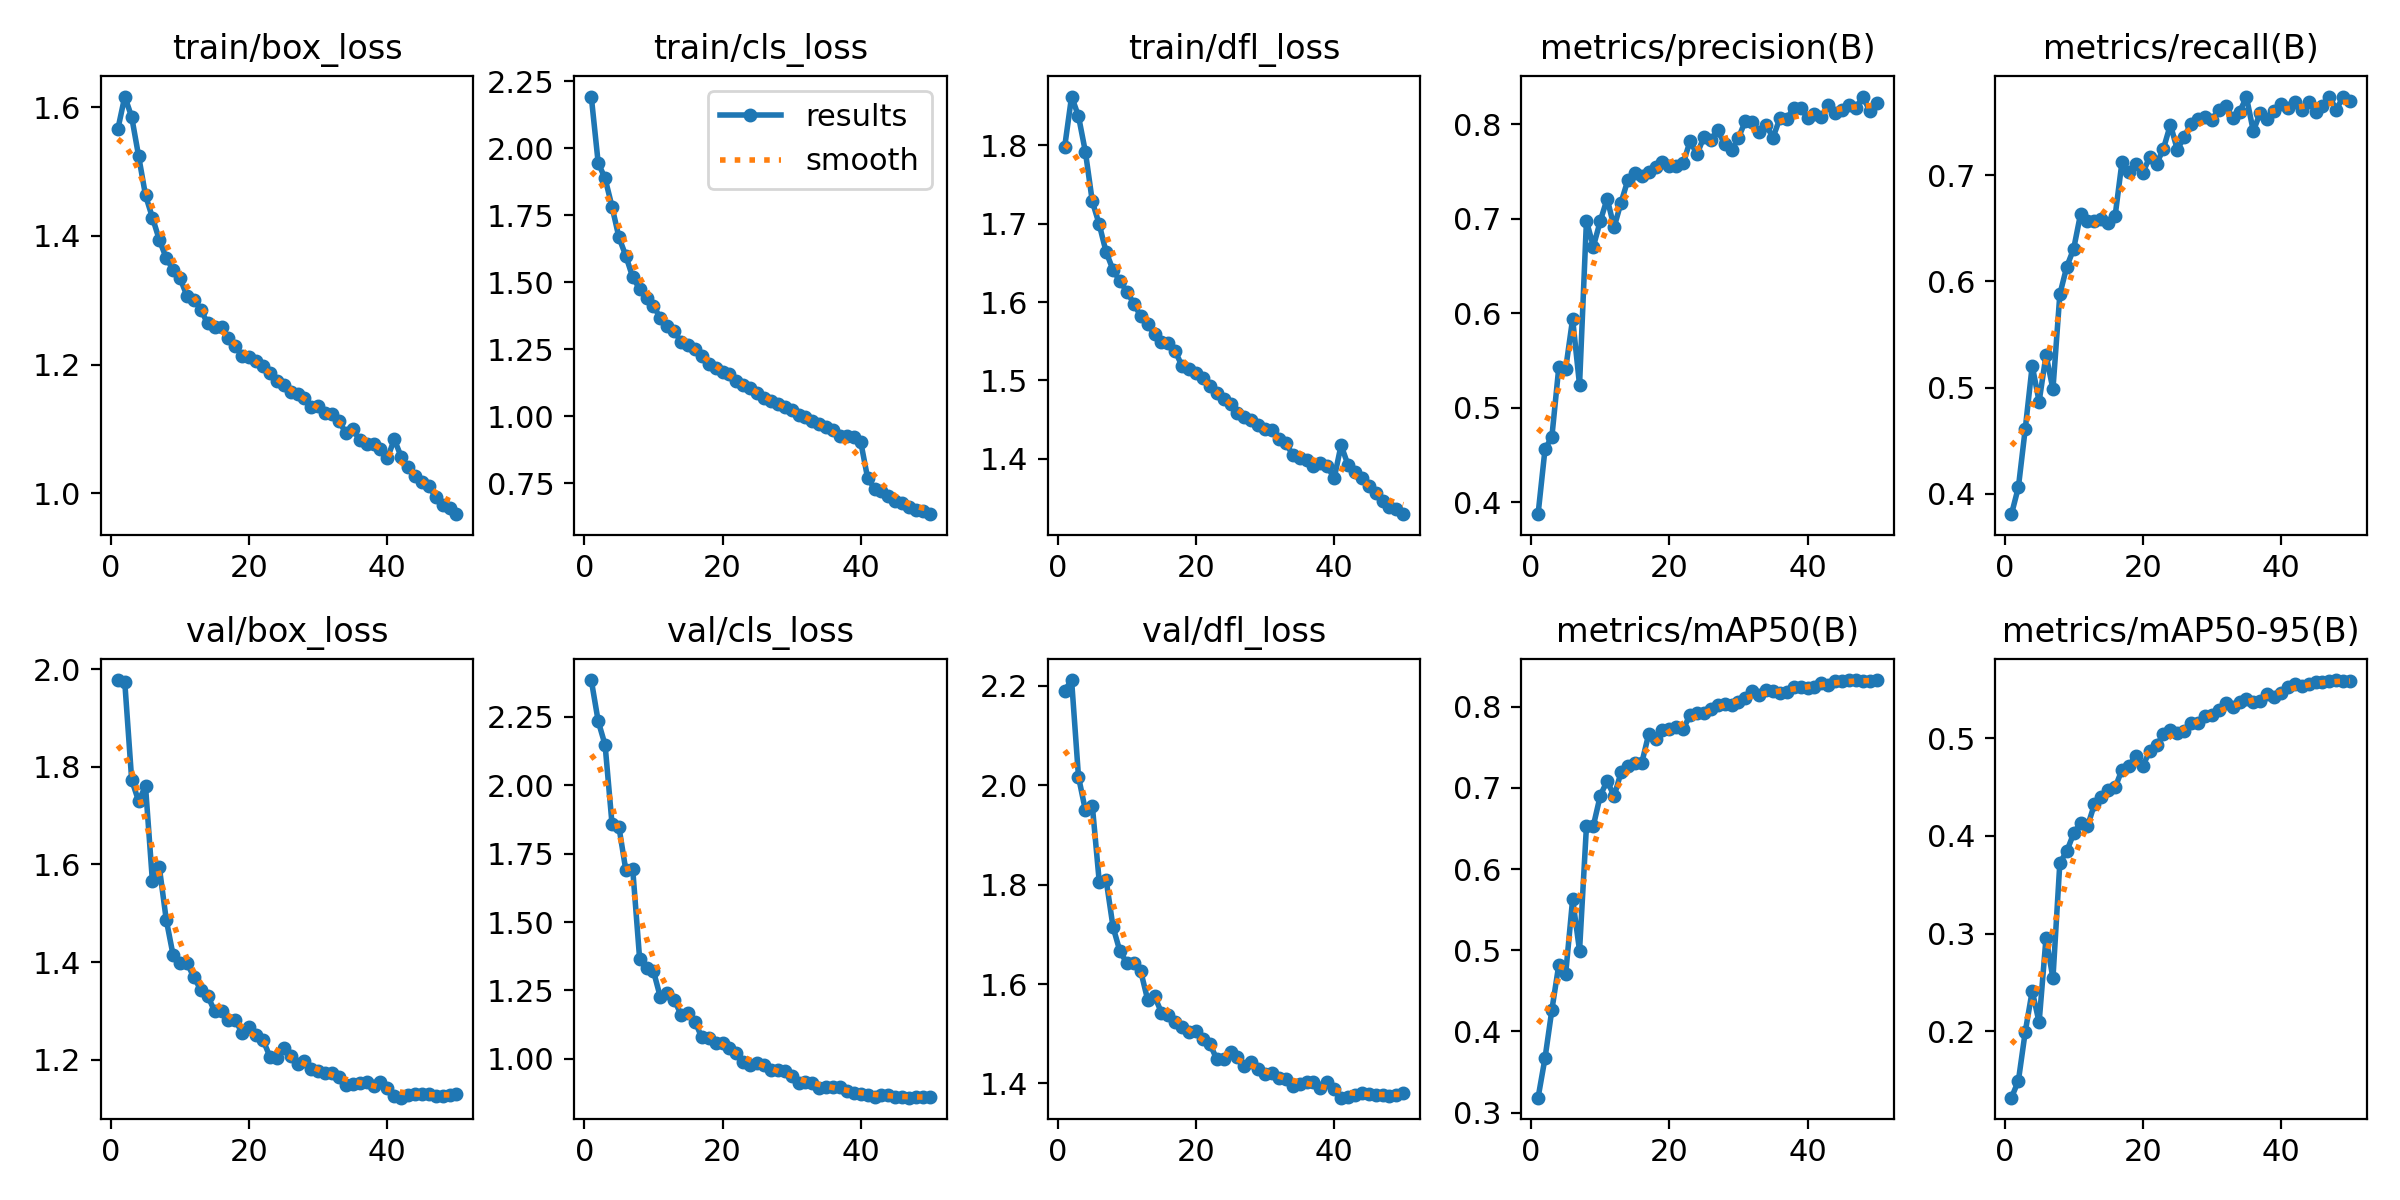

In [6]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/train/results.png")

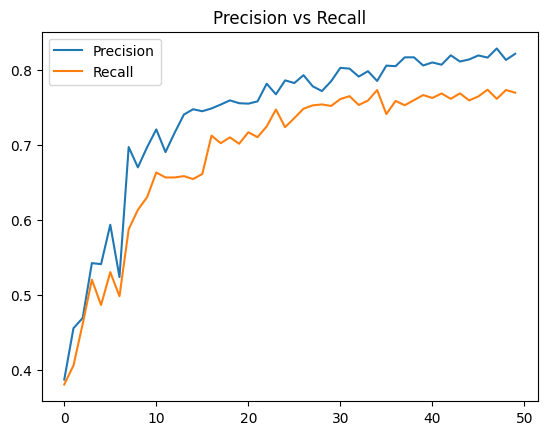

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")

# Precision & Recall
plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")
plt.legend()
plt.title("Precision vs Recall")
plt.show()

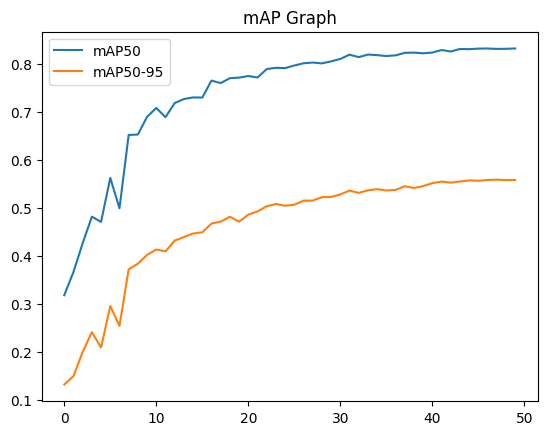

In [8]:
plt.plot(df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.legend()
plt.title("mAP Graph")
plt.show()

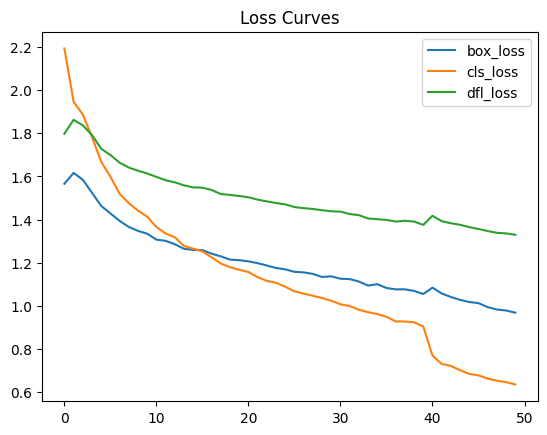

In [9]:
plt.plot(df["train/box_loss"], label="box_loss")
plt.plot(df["train/cls_loss"], label="cls_loss")
plt.plot(df["train/dfl_loss"], label="dfl_loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

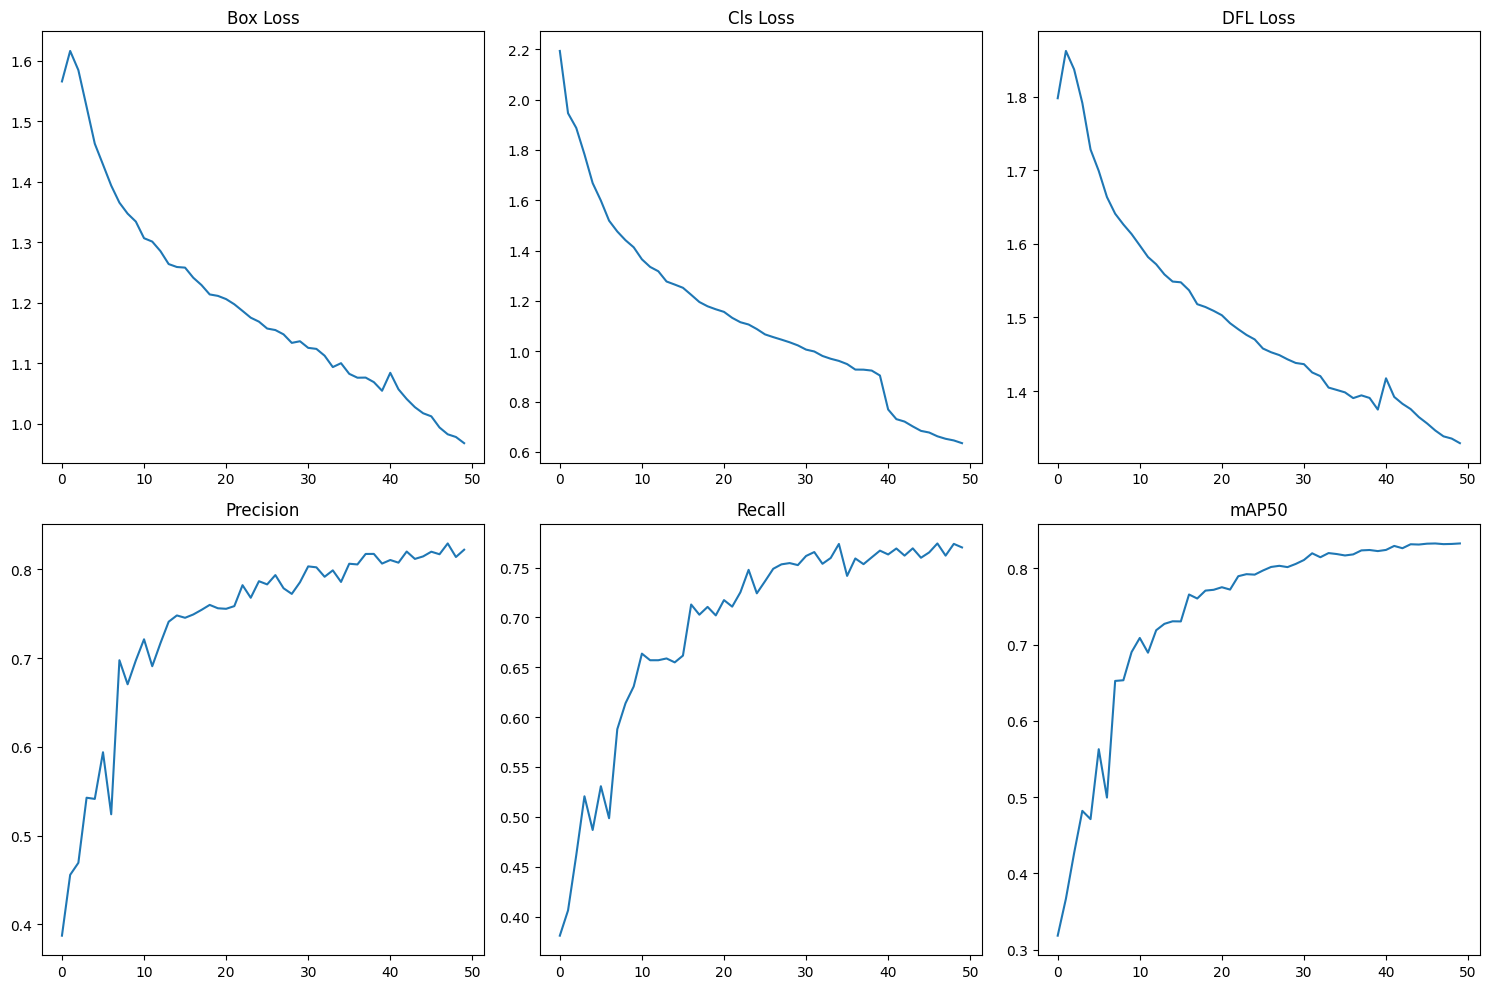

In [13]:
df = pd.read_csv("/kaggle/working/runs/detect/train/results.csv")

fig, axs = plt.subplots(2, 3, figsize=(15,10))

axs[0,0].plot(df["train/box_loss"]); axs[0,0].set_title("Box Loss")
axs[0,1].plot(df["train/cls_loss"]); axs[0,1].set_title("Cls Loss")
axs[0,2].plot(df["train/dfl_loss"]); axs[0,2].set_title("DFL Loss")

axs[1,0].plot(df["metrics/precision(B)"]); axs[1,0].set_title("Precision")
axs[1,1].plot(df["metrics/recall(B)"]); axs[1,1].set_title("Recall")
axs[1,2].plot(df["metrics/mAP50(B)"]); axs[1,2].set_title("mAP50")

plt.tight_layout()
plt.show()

In [15]:
from ultralytics import YOLO

DATA_PATH = "/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml"

def objective(params):
    lr, momentum = params

    model = YOLO("yolo12n.pt")

    model.train(
        data=DATA_PATH,
        epochs=3,   # ⚠️ fast
        imgsz=640,
        batch=16,
        lr0=float(lr),
        momentum=float(momentum),
        verbose=False
    )

    metrics = model.val(data=DATA_PATH)

    return float(metrics.box.map50)

In [17]:
import numpy as np

class GWO:
    def __init__(self, wolves=3, iterations=2):
        self.wolves = wolves
        self.iterations = iterations

    def optimize(self):
        wolves = np.random.rand(self.wolves, 2)

        best = None
        best_score = 0

        for i in range(self.iterations):
            print(f"GWO Iteration {i+1}")

            for w in wolves:
                lr = 0.0001 + w[0]*0.01
                momentum = 0.8 + w[1]*0.2

                score = objective([lr, momentum])

                print(f"lr={lr:.5f}, momentum={momentum:.3f}, score={score:.4f}")

                if score > best_score:
                    best_score = score
                    best = [lr, momentum]

        return best

In [18]:
class ABO:
    def __init__(self, buffalo=3, iterations=2):
        self.buffalo = buffalo
        self.iterations = iterations

    def optimize(self, start_point):
        best = start_point
        best_score = objective(best)

        for i in range(self.iterations):
            print(f"ABO Iteration {i+1}")

            for _ in range(self.buffalo):

                lr = best[0] + np.random.uniform(-0.002, 0.002)
                momentum = best[1] + np.random.uniform(-0.05, 0.05)

                # clip
                lr = max(0.0001, min(lr, 0.01))
                momentum = max(0.8, min(momentum, 0.99))

                score = objective([lr, momentum])

                print(f"lr={lr:.5f}, momentum={momentum:.3f}, score={score:.4f}")

                if score > best_score:
                    best_score = score
                    best = [lr, momentum]

        return best

In [19]:
gwo = GWO()
gwo_best = gwo.optimize()

print("GWO Best:", gwo_best)

abo = ABO()
final_best = abo.optimize(gwo_best)

print("Final Hybrid Best:", final_best)

GWO Iteration 1
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005588135039273248, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.943037873274484, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=Non

In [21]:
from ultralytics import YOLO

model = YOLO("yolo12n.pt")

model.train(
    data="/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    lr0=0.00558,
    momentum=0.943
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00558, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.943, mosaic=1.0, multi_scale=0.0, name=train16, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x799af3d35d30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [22]:
metrics = model.val(
    data="/kaggle/working/weapon_dataset/weapon-detection-yolov12/data.yaml",
    split="test"
)

print(metrics)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 914.9±414.4 MB/s, size: 48.8 KB)
val: Scanning /kaggle/working/weapon_dataset/weapon-detection-yolov12/test/labels... 1499 images, 204 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1499/1499 1.4Kit/s 1.0s0.0s
val: New cache created: /kaggle/working/weapon_dataset/weapon-detection-yolov12/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 6.1it/s 15.3s0.1s
                   all       1499       2691      0.847      0.807      0.871      0.617
------------------------------       1295       2691      0.847      0.807      0.871      0.617
Speed: 0.9ms preprocess, 5.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val14
ultralytics.utils.metrics.DetM